In [1]:
%load_ext autoreload
%autoreload 2

# Get parent directory and add to sys.path
import os
import sys

parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

# Require ipympl
%matplotlib widget 

In [2]:
rocket_obj_path = os.path.join(parent_dir, "Cartoon_rocket.obj")
rocket_params_path = os.path.join(parent_dir, "rocket.yaml")

In [3]:
from src.rocket import Rocket
from LinearMPC.MPCVelControl import MPCVelControl
import numpy as np
from src.vel_rocket_vis import *

# Rocket
Ts = 1.0 / 20.0
rocket = Rocket(Ts=Ts, model_params_filepath=rocket_params_path)
H = 3.0
mpc = MPCVelControl().new_controller(rocket, Ts, H)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



### Terminal invariant set

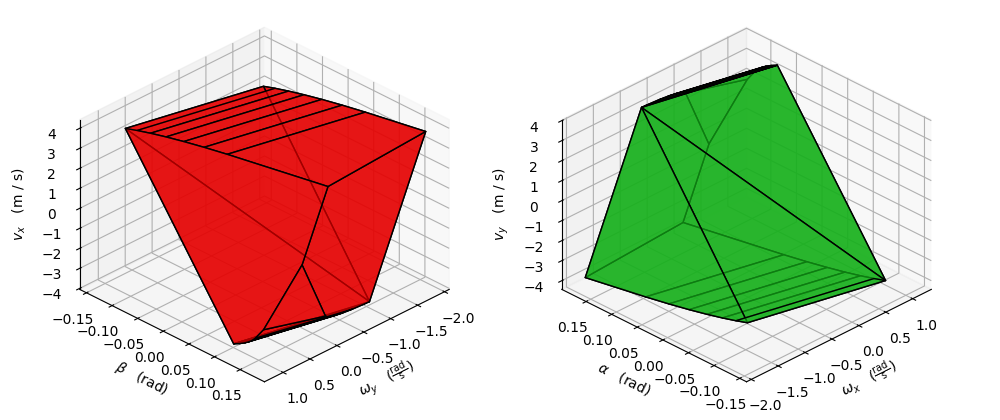

In [4]:
OPACITY = 0.7
X_COLOR = 'xkcd:red'
Y_COLOR = 'xkcd:green'

plt.close('all')
plt.figure('Terminal invariant set', (10, 4.2))

ax = plt.subplot(121, projection='3d', proj_type='ortho')
ax.view_init(elev=30, azim=45, roll=0)
mpc.mpc_x.O_inf.plot(ax, color=X_COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.set_xlabel(r'$\omega_y \quad (\frac{\text{rad}}{\text{s}})$')
ax.set_ylabel(r'$\beta \quad (\text{rad})$')
ax.set_zlabel(r'$v_x \quad (\text{m / s})$')
ax.grid()

ax = plt.subplot(122, projection='3d', proj_type='ortho')
ax.view_init(elev=30, azim=-135, roll=0)
mpc.mpc_y.O_inf.plot(ax, color=Y_COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.set_xlabel(r'$\omega_x \quad (\frac{\text{rad}}{\text{s}})$')
ax.set_ylabel(r'$\alpha \quad (\text{rad})$')
ax.set_zlabel(r'$v_y \quad (\text{m / s})$')
ax.grid()

plt.tight_layout(pad=0.5)
plt.show()
plt.savefig('terminal-set-3d')

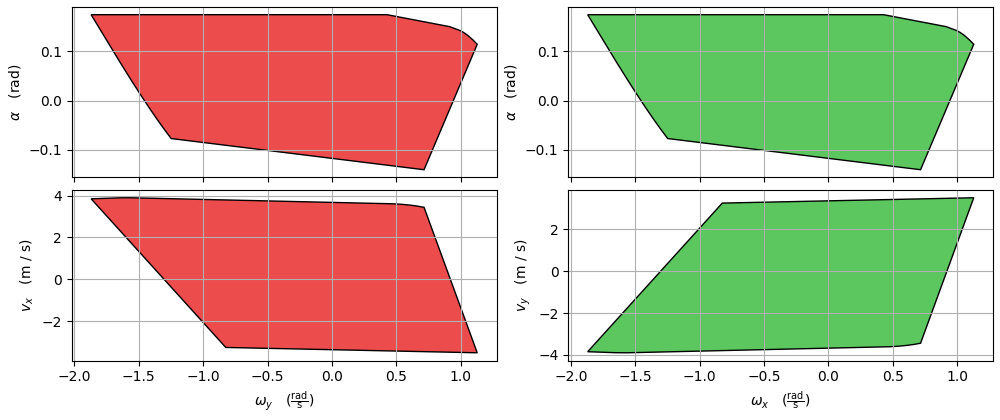

In [5]:
OPACITY = 0.7
X_COLOR = 'xkcd:red'
Y_COLOR = 'xkcd:green'

plt.close('all')
plt.figure('Terminal invariant set', (10, 4.2))

ax = plt.subplot(221)
mpc.mpc_x.O_inf.projection([0, 1]).plot(ax, color=X_COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.set_xticklabels([])
ax.set_ylabel(r'$\alpha \quad (\text{rad})$')
ax.grid()

ax = plt.subplot(223)
mpc.mpc_x.O_inf.projection([0, 2]).plot(ax, color=X_COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.set_xlabel(r'$\omega_y \quad (\frac{\text{rad}}{\text{s}})$')
ax.set_ylabel(r'$v_x \quad (\text{m / s})$')
ax.grid()

ax = plt.subplot(222)
mpc.mpc_y.O_inf.projection([0, 1]).plot(ax, color=Y_COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.set_xticklabels([])
ax.set_ylabel(r'$\alpha \quad (\text{rad})$')
ax.grid()

ax = plt.subplot(224)
mpc.mpc_y.O_inf.projection([0, 2]).plot(ax, color=Y_COLOR, opacity=OPACITY, show_edges=True, show_vertices=False)
ax.set_xlabel(r'$\omega_x \quad (\frac{\text{rad}}{\text{s}})$')
ax.set_ylabel(r'$v_y \quad (\text{m / s})$')
ax.grid()

plt.tight_layout(pad=0.5)
plt.show()
plt.savefig('terminal-set-2d')

### First case : 5 m/s in x, y, z

In [6]:
# Initial state
t0 = 0.0
x0 = np.array([
    0.0, 0.0, 0.0,	# omega
    0.0, 0.0, 0.0,	# r
    5.0, 5.0, 5.0,	# v
    0.0, 0.0, 0.0	# p
])
u0 = mpc.us

# Closed loop simulation
sim_time = 7.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, method="linear"
)

Simulating time 0.00: 

c:\Users\killi\Desktop\MPC-Course-EPFL\.env\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(



Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
Simulating time 0.40: 
Simulating time 0.45: 
Simulating time 0.50: 
Simulating time 0.55: 
Simulating time 0.60: 
Simulating time 0.65: 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
Simulating time 0.85: 
Simulating time 0.90: 
Simulating time 0.95: 
Simulating time 1.00: 
Simulating time 1.05: 
Simulating time 1.10: 
Simulating time 1.15: 
Simulating time 1.20: 
Simulating time 1.25: 
Simulating time 1.30: 
Simulating time 1.35: 
Simulating time 1.40: 
Simulating time 1.45: 
Simulating time 1.50: 
Simulating time 1.55: 
Simulating time 1.60: 
Simulating time 1.65: 
Simulating time 1.70: 
Simulating time 1.75: 
Simulating time 1.80: 
Simulating time 1.85: 
Simulating time 1.90: 
Simulating time 1.95: 
Simulating time 2.00: 
Simulating time 2.05: 
Simulating time 2.10: 
Simulating time 2.15: 
Simulating

In [7]:
# Visualize simulation
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol)

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x0000013F2CEF6180> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.13_3.13.2544.0_x64__qbz5n2kfra8p0\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: cannot enter context: <_contextvars.Context object at 0x0000013F2CEF6180> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most rec

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=139, step=2), IntSlider(value=0…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\alpha\\beta\\gamma}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: >,
  <Axes: ylabel='$\\alpha\\beta\\gamma$ (deg)'>,
  <Axes: >,
  <Axes: ylabel='$v$ (m/s)'>,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: ylabel='$\\text{pos}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x13f7f7b8ec0>,
 'scene_objects': {'rocket_actor': Actor (0x13fc543dba0)
    Center:                     (0.32006999999999997, -0.0015085000000000237, 0.5884844999999999)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    -6.402E-01, 1.280E+00
    Y Bounds                    -1.21

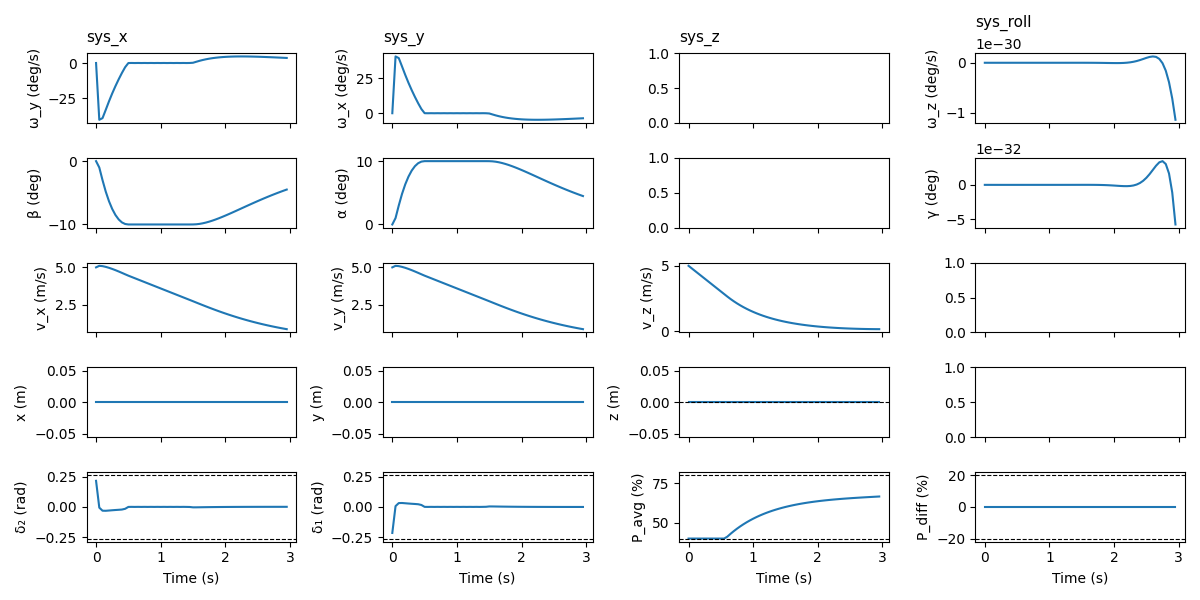

In [8]:
plot_static_states_inputs(t_ol[:-1, 0], x_ol[:,:-1, 0], u_ol[:, :, 0])
plt.savefig('5ms-stab-open-loop')

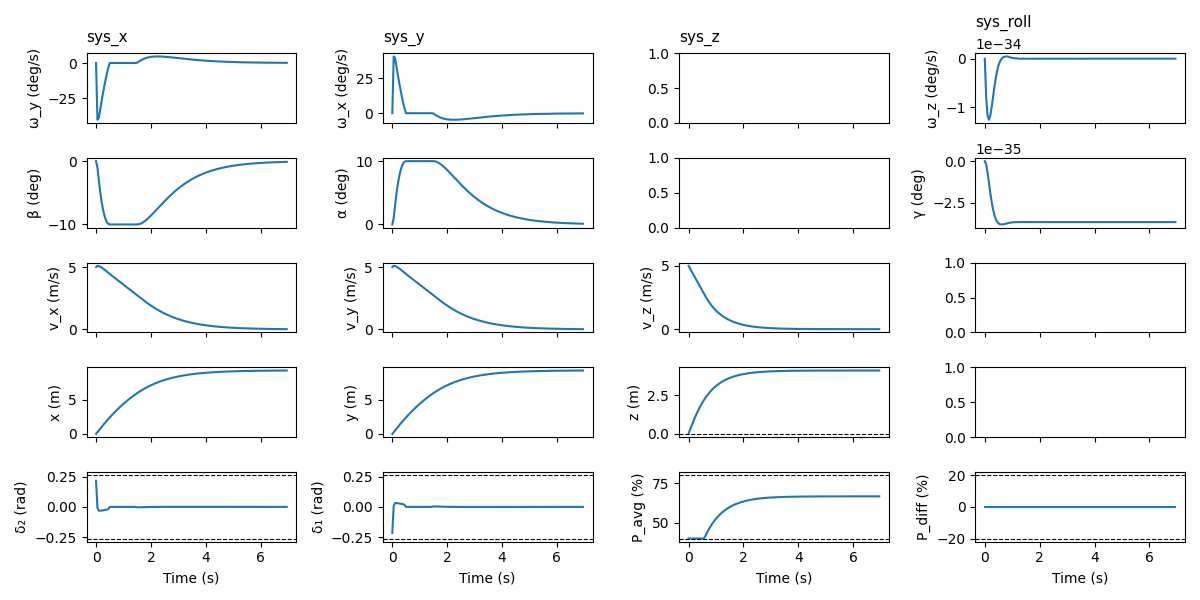

In [9]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl)
plt.savefig('5ms-stab-closed-loop')

### Second case : 30° roll angle

In [10]:
# Initial state
t0 = 0.0
x0 = np.array([
    0.0, 0.0, 0.0,	# omega
    0.0, 0.0, np.deg2rad(30),	# r
    0.0, 0.0, 0.0,	# v
    0.0, 0.0, 0.0	# p
])
u0 = mpc.us

# Closed loop simulation
sim_time = 7.0
t_cl, x_cl, u_cl, t_ol, x_ol, u_ol, _ = rocket.simulate_control(
    mpc, sim_time, H, x0, method="linear"
)

Simulating time 0.00: 
Simulating time 0.05: 
Simulating time 0.10: 
Simulating time 0.15: 
Simulating time 0.20: 
Simulating time 0.25: 
Simulating time 0.30: 
Simulating time 0.35: 
Simulating time 0.40: 
Simulating time 0.45: 
Simulating time 0.50: 
Simulating time 0.55: 
Simulating time 0.60: 
Simulating time 0.65: 
Simulating time 0.70: 
Simulating time 0.75: 
Simulating time 0.80: 
Simulating time 0.85: 
Simulating time 0.90: 
Simulating time 0.95: 
Simulating time 1.00: 
Simulating time 1.05: 
Simulating time 1.10: 
Simulating time 1.15: 
Simulating time 1.20: 
Simulating time 1.25: 
Simulating time 1.30: 
Simulating time 1.35: 
Simulating time 1.40: 
Simulating time 1.45: 
Simulating time 1.50: 
Simulating time 1.55: 
Simulating time 1.60: 
Simulating time 1.65: 
Simulating time 1.70: 
Simulating time 1.75: 
Simulating time 1.80: 
Simulating time 1.85: 
Simulating time 1.90: 
Simulating time 1.95: 
Simulating time 2.00: 
Simulating time 2.05: 
Simulating time 2.10: 
Simulating 

In [11]:
# Visualize simulation
vis = RocketVis(rocket, rocket_obj_path)
vis.anim_rate = 1.0
vis.animate(t_cl[:-1], x_cl[:, :-1], u_cl, T_ol=t_ol[..., :-1], X_ol=x_ol, U_ol=u_ol)

AppLayout(children=(HBox(children=(Play(value=0, description='Press play', max=139, step=2), IntSlider(value=0…

{'fig': <Figure size 640x480 with 16 Axes>,
 'axes': [<Axes: ylabel='inputs'>,
  <Axes: >,
  <Axes: >,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Y'}>,
  <Axes: title={'center': 'Subsystem X'}, ylabel='$\\omega_{\\alpha\\beta\\gamma}$ (deg/s)'>,
  <Axes: title={'center': 'Subsystem Roll'}>,
  <Axes: >,
  <Axes: ylabel='$\\alpha\\beta\\gamma$ (deg)'>,
  <Axes: >,
  <Axes: ylabel='$v$ (m/s)'>,
  <Axes: >,
  <Axes: title={'center': 'Subsystem Z'}>,
  <Axes: ylabel='$\\text{pos}$ (m)'>,
  <Axes: >,
  <Axes: >],
 'plotter': <pyvista.plotting.plotter.Plotter at 0x13fcf9c7250>,
 'scene_objects': {'rocket_actor': Actor (0x13fcfa157e0)
    Center:                     (0.06035644045648636, -0.21257898309336398, 0.5884844999999999)
    Pickable:                   True
    Position:                   (0.0, 0.0, 0.0)
    Scale:                      (1.0, 1.0, 1.0)
    Visible:                    True
    X Bounds                    -1.002E+00, 1.122E+00
    Y Bounds                    -1.264E

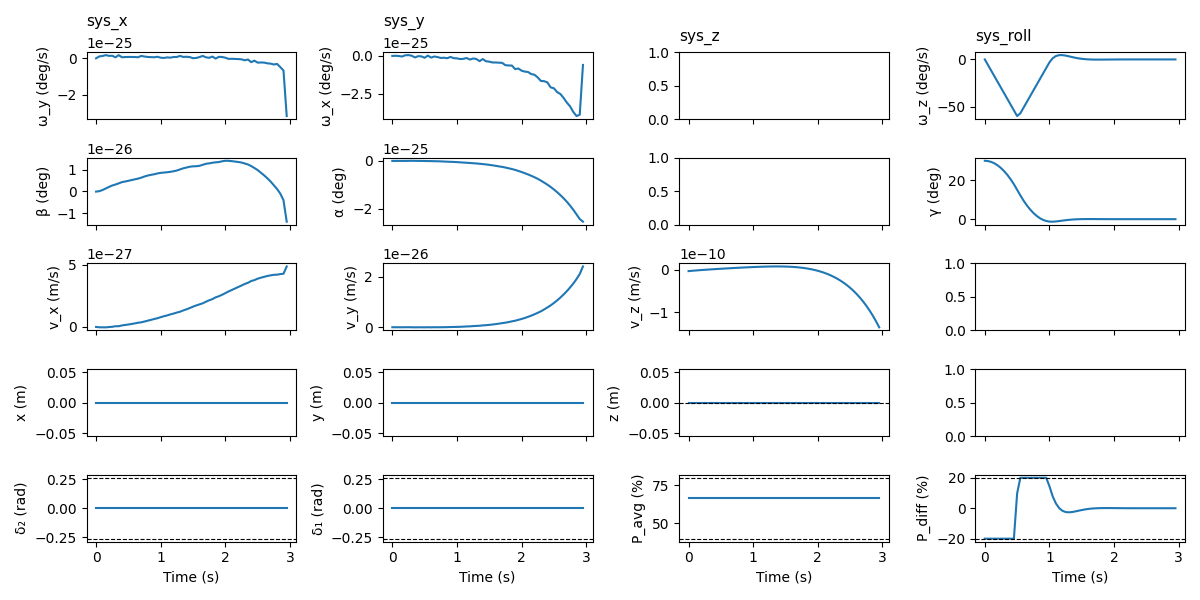

In [12]:
plot_static_states_inputs(t_ol[:-1, 0], x_ol[:,:-1, 0], u_ol[:, :, 0])
plt.savefig('30roll-stab-open-loop')

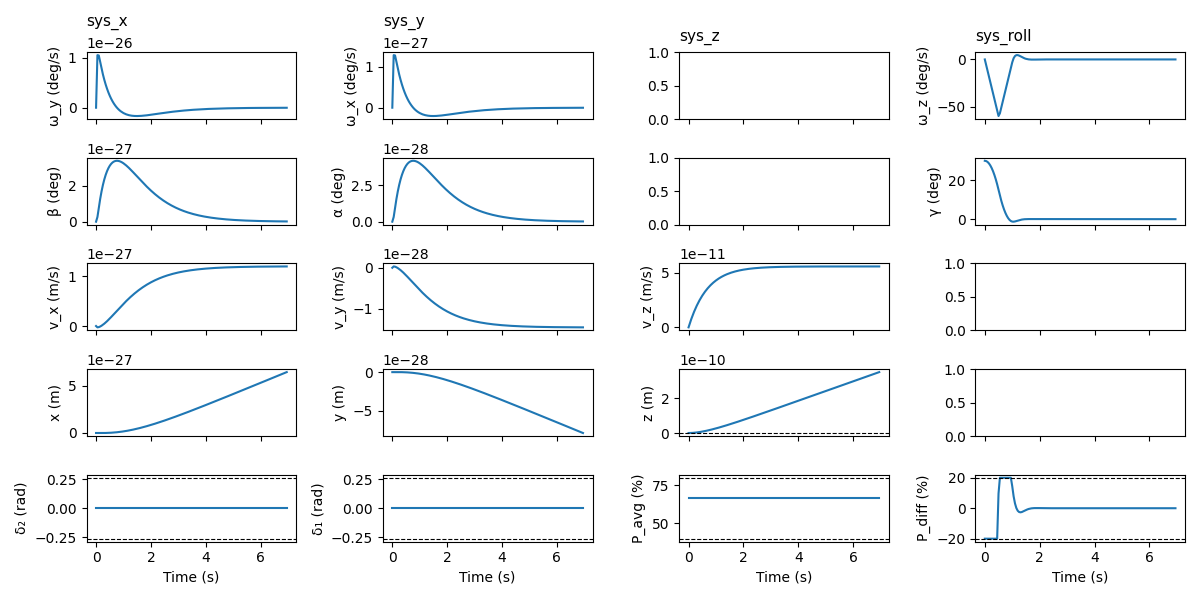

In [13]:
plot_static_states_inputs(t_cl[:-1], x_cl[:,:-1], u_cl)
plt.savefig('30roll-stab-closed-loop')